<a href="https://colab.research.google.com/github/dhiru234/projectand-normal-deep-learning-and-machine-learning/blob/main/DSC_VOE_IOE_21labels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!python -c "import monai" || pip install -q "monai-weekly[gdown, nibabel, tqdm, ignite]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.9 MB/s eta 0:00:00


In [ ]:
from monai.utils import first, set_determinism
from monai.transforms import (
    AsDiscrete,
    AsDiscreted,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    SaveImaged,
    ScaleIntensityd,
    Spacingd,
    Invertd,
    ToTensord,
    Resized,
    Lambdad,
)
from monai.handlers.utils import from_engine
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.metrics import DiceMetric
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch
from monai.config import print_config
from monai.apps import download_and_extract
import torch
import matplotlib.pyplot as plt
import tempfile
import shutil
import os
from glob import glob
import numpy as np
import nibabel as nib

print_config()

MONAI version: 1.4.dev2431
Numpy version: 1.26.4
Pytorch version: 2.3.1+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 951a77d7a7737a3108afa94623a50b87d21eb4a7
MONAI __file__: /usr/local/lib/python3.10/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.0.1
scikit-image version: 0.23.2
scipy version: 1.13.1
Pillow version: 9.4.0
Tensorboard version: 2.17.0
gdown version: 4.7.3
TorchVision version: 0.18.1+cu121
tqdm version: 4.66.5
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.1.4
einops version: 0.8.0
transformers version: 4.42.4
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.htm

In [ ]:
drive_directory = '/content/drive/MyDrive/ALL_METRICS_DATA_DIRECTORY'

os.makedirs(drive_directory, exist_ok=True)

directory = drive_directory if os.path.exists(drive_directory) else os.environ.get("ALL_METRICS_DATA_DIRECTORY")
root_dir = directory if directory is not None else tempfile.mkdtemp()

print(f"The directory has been set to: {root_dir}")


The directory has been set to: /content/drive/MyDrive/ALL_METRICS_DATA_DIRECTORY


In [ ]:
image_directory='/content/drive/MyDrive/OASIS3_Dataset_Part4/Image_Folder'
label_directory='/content/drive/MyDrive/OASIS3_Dataset_Part4/Label_Folder'

In [ ]:
image_files=sorted(glob(f'{image_directory}/**/*.nii.gz*',recursive=True))
label_files=sorted(glob(f'{label_directory}/**/*.nii.gz*',recursive=True))

In [ ]:
len(image_files),len(label_files)

(84, 84)

In [ ]:
colormap_path = '/content/drive/MyDrive/FreeSurferColorLUT.txt'

In [ ]:
# Create a Custom Colormap Array in consistent with FreeSurfer
from matplotlib import colors
STD_LABEL_VALUES=np.array([0,2,3,4,5,7,8,10,11,12,13,14,15,16,17,18,24,26,28,30,31,41,42,43,44,46,47,49,50,51,52,53,54,58,60,62,63,77,80,85,251,252,253,254,255])
RED_LABEL_VALUES=np.array([0,2,3,4,10,11,12,13,16,17,18,26,41,42,43,49,50,51,52,53,54,58])
print(f'Reduced Label Values \n',RED_LABEL_VALUES)
print(f'Number of Standard Label Values=',len(STD_LABEL_VALUES),'\n Number of Reduced Label Values=',len(RED_LABEL_VALUES))

Reduced Label Values 
 [ 0  2  3  4 10 11 12 13 16 17 18 26 41 42 43 49 50 51 52 53 54 58]
Number of Standard Label Values= 45 
 Number of Reduced Label Values= 22


In [ ]:
patient_data=[{'image':images,'label':labels} for images,labels in zip(image_files,label_files)]
train_data=patient_data[:60]
val_data=patient_data[60:]
print(f'Size of Train Files=',len(train_data),'\n Size of Validation Files=',len(val_data))

Size of Train Files= 60 
 Size of Validation Files= 24


In [ ]:
data=np.loadtxt(colormap_path,dtype=str)
label_index=data[:,0].astype(np.int16)
label_cmap=data[:,2:5].astype(np.int16)/255
red_cmap_array1=np.zeros((28,3))
for j,label in zip(range(len(RED_LABEL_VALUES)),RED_LABEL_VALUES):
  Loc1=np.where(label_index==label)[0][0]
  red_cmap_array1[j]=label_cmap[Loc1]

In [ ]:
def Replace_Red_FS_Index(Label_data):
  dis_ele=np.setdiff1d(STD_LABEL_VALUES,RED_LABEL_VALUES)
  for items in dis_ele:
    Label_data[Label_data==items]=0
  for elements in RED_LABEL_VALUES:
    Label_data[Label_data==elements]=np.where(RED_LABEL_VALUES==elements)[0][0]
  return Label_data

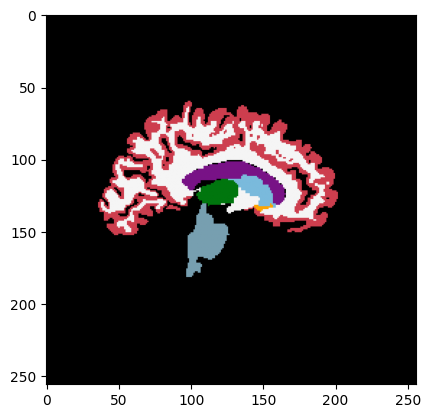

In [ ]:
img_data=nib.load(image_files[0]).get_fdata()
label_data=nib.load(label_files[0]).get_fdata()
mod_label_data1=Replace_Red_FS_Index(label_data)
col_mod_label_data1=red_cmap_array1[mod_label_data1.astype(np.int16)]
plt.imshow(col_mod_label_data1[118,:,:])
plt.show()

In [ ]:
ext_img_data=np.expand_dims(img_data,axis=0)
ext_label_data=np.expand_dims(label_data,axis=0)


In [ ]:
set_determinism(seed=0)

In [ ]:
red_train_transforms=Compose(
    [
        LoadImaged(keys=["image", "label"]),
        Lambdad(keys="label",func=Replace_Red_FS_Index),
        ToTensord(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Resized(keys=["image","label"],spatial_size=(128,128,128),mode=['area','nearest']),
        ScaleIntensityd(keys="image", minv=0, maxv=1),
    ]
)
red_val_transforms=Compose(
    [
        LoadImaged(keys=["image", "label"]),
        Lambdad(keys="label",func=Replace_Red_FS_Index),
        ToTensord(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Resized(keys=["image","label"],spatial_size=(128,128,128),mode=['area','nearest']),
        ScaleIntensityd(keys="image", minv=0, maxv=1),
    ]
)

In [ ]:
Red_train_ds = Dataset(data=train_data, transform=red_train_transforms)
Red_train_loader = DataLoader(Red_train_ds, batch_size=1, shuffle=True, num_workers=0)
Red_val_ds = Dataset(data=val_data, transform=red_val_transforms)
Red_val_loader = DataLoader(Red_val_ds, batch_size=1, num_workers=0)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

red_model= UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=28,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
red_optimizer= torch.optim.Adam(red_model.parameters(), 1e-3)
dice_metric = DiceMetric(include_background=False, reduction="mean")

cuda


In [ ]:
max_epochs = 60
val_interval = 2
early_stopping_patience = 10
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
dice_values = []
voe_values = []
iou_values = []
early_stop_counter = 0

# Initialize transforms for post-processing
post_pred = Compose([AsDiscrete(argmax=True, to_onehot=28)])  # Adjust to 28 labels
post_label = Compose([AsDiscrete(to_onehot=28)])

# Define function to save checkpoint
def save_checkpoint(model, optimizer, epoch, best_metric, best_metric_epoch, path, epoch_loss_values, dice_values, voe_values, iou_values):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_metric': best_metric,
        'best_metric_epoch': best_metric_epoch,
        'epoch_loss_values': epoch_loss_values,
        'dice_values': dice_values,
        'voe_values': voe_values,
        'iou_values': iou_values
    }, path)

# Define function to load checkpoint
def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    return checkpoint['epoch'], checkpoint['best_metric'], checkpoint['best_metric_epoch'], checkpoint.get('epoch_loss_values', []), checkpoint.get('dice_values', []), checkpoint.get('voe_values', []), checkpoint.get('iou_values', [])

checkpoint_path = os.path.join(root_dir, "checkpoint.pth")

# Initialize metrics
dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)

# Define functions to calculate VOE and IoU
def compute_voe(pred, target):
    intersection = torch.sum(pred * target)
    union = torch.sum(pred) + torch.sum(target) - intersection
    voe = 1 - intersection / union
    return voe.item()

def compute_iou(pred, target):
    intersection = torch.sum(pred * target)
    union = torch.sum(pred) + torch.sum(target) - intersection
    iou = intersection / union
    return iou.item()

# Load from checkpoint if it exists
start_epoch = 0
if os.path.exists(checkpoint_path):
    start_epoch, best_metric, best_metric_epoch, epoch_loss_values, dice_values, voe_values, iou_values = load_checkpoint(model, optimizer, checkpoint_path)
    print(f"Resuming from epoch {start_epoch}, best metric: {best_metric:.4f} at epoch {best_metric_epoch}")

for epoch in range(start_epoch, max_epochs):
    print("-" * 10)
    print(f"Epoch {epoch + 1}/{max_epochs}")
    red_model.train()
    epoch_loss = 0
    step = 0

    for batch_data in Red_train_loader:
        step += 1
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )
        red_optimizer.zero_grad()
        outputs = red_model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        red_optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(Red_train_loader)}, train_loss: {loss.item():.4f}")

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"Epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    # Validation
    if (epoch + 1) % val_interval == 0:
        red_model.eval()
        with torch.no_grad():
            # Initialize metrics for validation
            dice_metric.reset()
            voe_sum = 0
            iou_sum = 0
            count = 0

            for val_data in Red_val_loader:
                val_inputs, val_labels = (
                    val_data["image"].to(device),
                    val_data["label"].to(device),
                )
                roi_size = (128, 128, 128)
                sw_batch_size = 4
                val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, red_model)
                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels = [post_label(i) for i in decollate_batch(val_labels)]

                dice_metric(y_pred=val_outputs, y=val_labels)

                voe = compute_voe(val_outputs[0], val_labels[0])
                iou = compute_iou(val_outputs[0], val_labels[0])
                voe_sum += voe
                iou_sum += iou
                count += 1

            # Aggregate the final mean metrics
            mean_dice = dice_metric.aggregate().item()
            mean_voe = voe_sum / count
            mean_iou = iou_sum / count
            dice_values.append(mean_dice)
            voe_values.append(mean_voe)
            iou_values.append(mean_iou)

            # Check for best metric and save model
            if mean_dice > best_metric:
                best_metric = mean_dice
                best_metric_epoch = epoch + 1
                save_checkpoint(red_model, red_optimizer, epoch + 1, best_metric, best_metric_epoch, os.path.join(root_dir, "best_metric_model.pth"), epoch_loss_values, dice_values, voe_values, iou_values)
                print("Saved new best metric model")
                early_stop_counter = 0  # Reset early stop counter if there's improvement
            else:
                early_stop_counter += 1  # Increment early stop counter if no improvement

            print(f"Current epoch: {epoch + 1} current mean dice: {mean_dice:.4f}, mean VOE: {mean_voe:.4f}, mean IoU: {mean_iou:.4f}"
                  f"\nBest mean dice: {best_metric:.4f} at epoch: {best_metric_epoch}")

    # Save checkpoint every epoch
    save_checkpoint(red_model, red_optimizer, epoch + 1, best_metric, best_metric_epoch, checkpoint_path, epoch_loss_values, dice_values, voe_values, iou_values)

    # Early stopping
    if early_stop_counter >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch + 1} epochs.")
        break

print(f"Training completed. Best metric: {best_metric:.4f} at epoch {best_metric_epoch}")


----------
Epoch 1/60
1/60, train_loss: 0.9953
2/60, train_loss: 0.9913
3/60, train_loss: 0.9871
4/60, train_loss: 0.9862
5/60, train_loss: 0.9809
6/60, train_loss: 0.9781
7/60, train_loss: 0.9735
8/60, train_loss: 0.9703
9/60, train_loss: 0.9675
10/60, train_loss: 0.9620
11/60, train_loss: 0.9559
12/60, train_loss: 0.9579
13/60, train_loss: 0.9439
14/60, train_loss: 0.9420
15/60, train_loss: 0.9456
16/60, train_loss: 0.9332
17/60, train_loss: 0.9302
18/60, train_loss: 0.9320
19/60, train_loss: 0.9236
20/60, train_loss: 0.9230
21/60, train_loss: 0.9133
22/60, train_loss: 0.9085
23/60, train_loss: 0.9066
24/60, train_loss: 0.9042
25/60, train_loss: 0.9033
26/60, train_loss: 0.8984
27/60, train_loss: 0.8976
28/60, train_loss: 0.8972
29/60, train_loss: 0.8963
30/60, train_loss: 0.9005
31/60, train_loss: 0.8882
32/60, train_loss: 0.8863
33/60, train_loss: 0.8852
34/60, train_loss: 0.8744
35/60, train_loss: 0.8839
36/60, train_loss: 0.8827
37/60, train_loss: 0.8877
38/60, train_loss: 0.8839

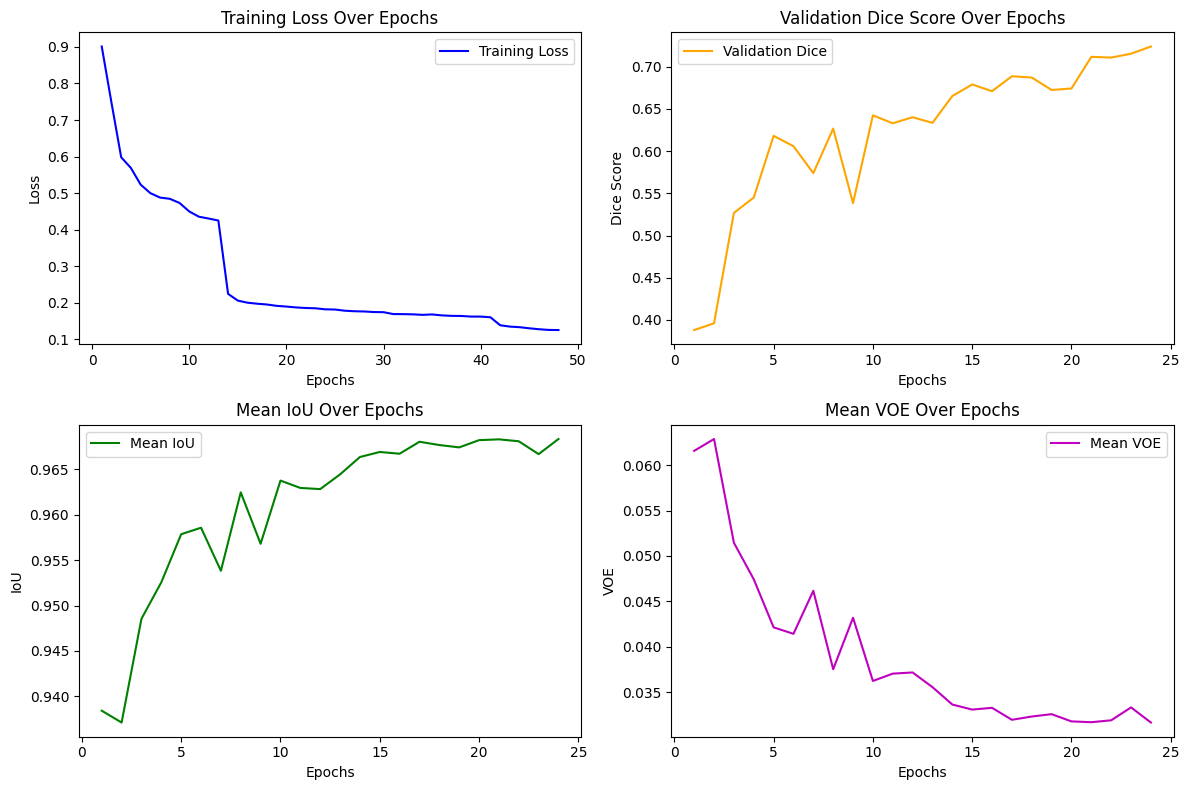

In [ ]:
import torch
import matplotlib.pyplot as plt
import os

# Define the path to your checkpoint file
checkpoint_path = os.path.join(root_dir, "best_metric_model.pth")

# Define function to load checkpoint
def load_checkpoint(path):
    try:
        checkpoint = torch.load(path)
        return (checkpoint['epoch'], checkpoint['best_metric'], checkpoint['best_metric_epoch'],
                checkpoint.get('epoch_loss_values', []), checkpoint.get('dice_values', []),
                checkpoint.get('voe_values', []), checkpoint.get('iou_values', []))
    except Exception as e:
        print(f"Error loading checkpoint: {e}")
        return 0, -1, -1, [], [], [], []

# Load metrics from checkpoint
start_epoch, best_metric, best_metric_epoch, epoch_loss_values, dice_values, voe_values, iou_values = load_checkpoint(checkpoint_path)

# Define epochs
epochs = range(1, len(dice_values) + 1)  # assuming epoch starts from 1 and continues sequentially

# Create plots
plt.figure(figsize=(12, 8))

# Plot Training Loss values
plt.subplot(2, 2, 1)
plt.plot(range(1, len(epoch_loss_values) + 1), epoch_loss_values, 'b-', label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# Plot Validation Dice values
plt.subplot(2, 2, 2)
plt.plot(epochs, dice_values, 'orange', label='Validation Dice')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.title('Validation Dice Score Over Epochs')
plt.legend()

# Plot IoU values
plt.subplot(2, 2, 3)
plt.plot(epochs, iou_values, 'g-', label='Mean IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.title('Mean IoU Over Epochs')
plt.legend()

# Plot VOE values
plt.subplot(2, 2, 4)
plt.plot(epochs, voe_values, 'm-', label='Mean VOE')
plt.xlabel('Epochs')
plt.ylabel('VOE')
plt.title('Mean VOE Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()


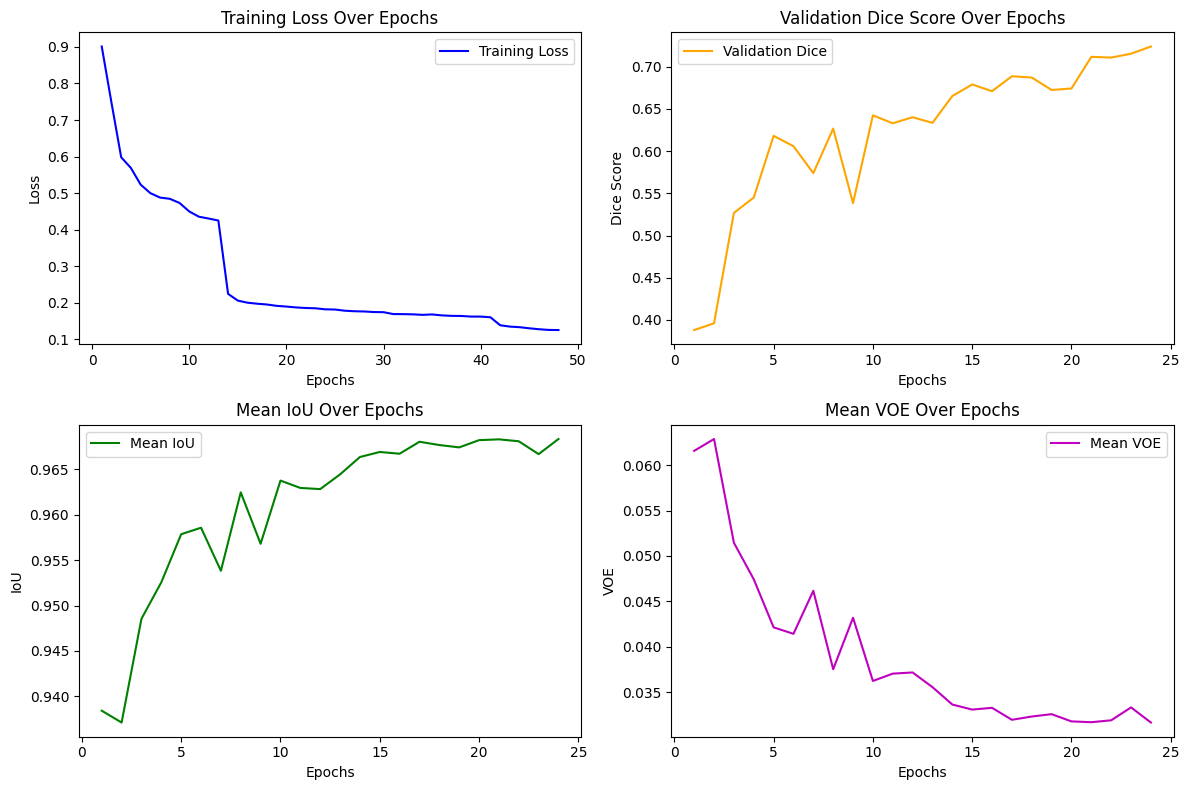

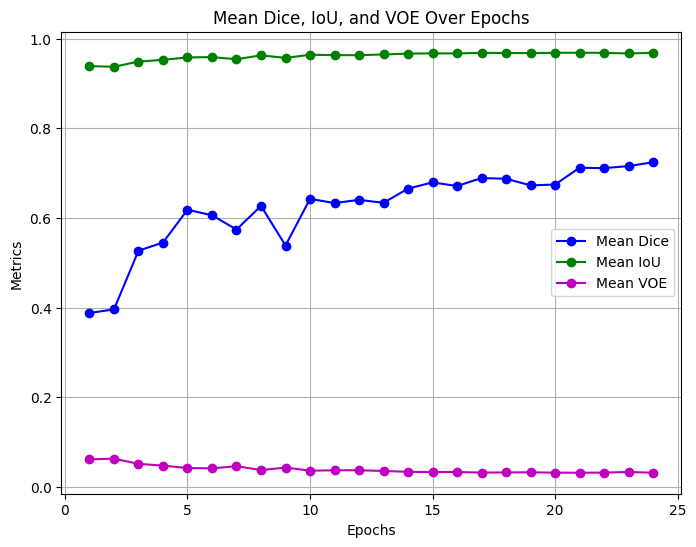

In [ ]:
import torch
import matplotlib.pyplot as plt
import os

# Define the path to your checkpoint file
checkpoint_path = os.path.join(root_dir, "best_metric_model.pth")

# Define function to load checkpoint
def load_checkpoint(path):
    try:
        checkpoint = torch.load(path)
        return (checkpoint['epoch'], checkpoint['best_metric'], checkpoint['best_metric_epoch'],
                checkpoint.get('epoch_loss_values', []), checkpoint.get('dice_values', []),
                checkpoint.get('voe_values', []), checkpoint.get('iou_values', []))
    except Exception as e:
        print(f"Error loading checkpoint: {e}")
        return 0, -1, -1, [], [], [], []

# Load metrics from checkpoint
start_epoch, best_metric, best_metric_epoch, epoch_loss_values, dice_values, voe_values, iou_values = load_checkpoint(checkpoint_path)

# Define epochs
epochs = range(1, len(dice_values) + 1)  # assuming epoch starts from 1 and continues sequentially

# Create separate plots in a 2x2 grid
plt.figure(figsize=(12, 8))

# Plot Training Loss values
plt.subplot(2, 2, 1)
plt.plot(range(1, len(epoch_loss_values) + 1), epoch_loss_values, 'b-', label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# Plot Validation Dice values
plt.subplot(2, 2, 2)
plt.plot(epochs, dice_values, 'orange', label='Validation Dice')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.title('Validation Dice Score Over Epochs')
plt.legend()

# Plot IoU values
plt.subplot(2, 2, 3)
plt.plot(epochs, iou_values, 'g-', label='Mean IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.title('Mean IoU Over Epochs')
plt.legend()

# Plot VOE values
plt.subplot(2, 2, 4)
plt.plot(epochs, voe_values, 'm-', label='Mean VOE')
plt.xlabel('Epochs')
plt.ylabel('VOE')
plt.title('Mean VOE Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

# Plot mean Dice, mean IoU, and mean VOE on a single graph
plt.figure(figsize=(8, 6))
plt.plot(epochs, dice_values, 'b-', marker='o', label='Mean Dice')
plt.plot(epochs, iou_values, 'g-', marker='o', label='Mean IoU')
plt.plot(epochs, voe_values, 'm-', marker='o', label='Mean VOE')
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.title('Mean Dice, IoU, and VOE Over Epochs')
plt.legend()
plt.grid(True)
plt.show()


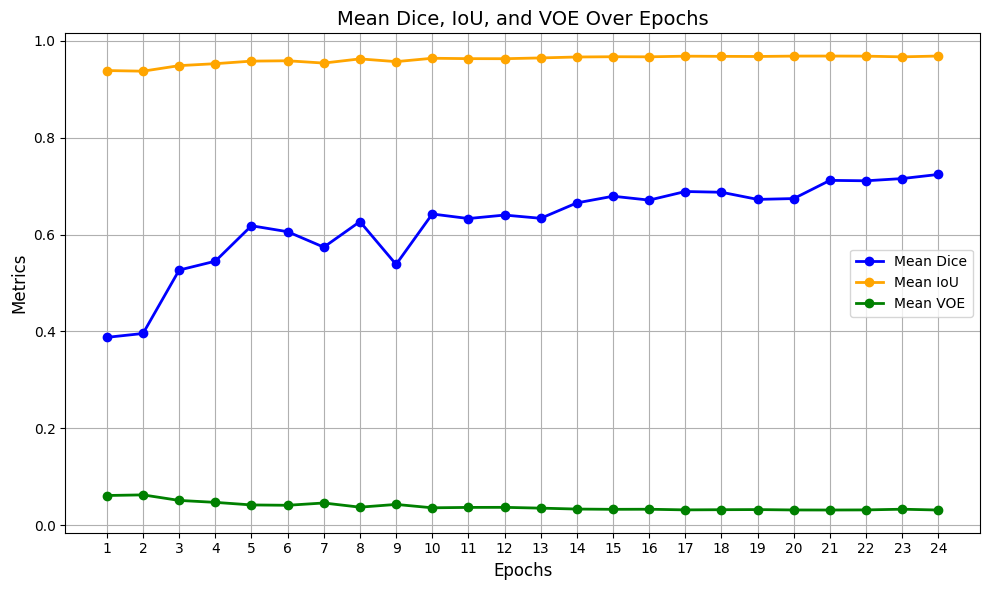

In [ ]:
import torch
import matplotlib.pyplot as plt
import os

# Define the path to your checkpoint file
checkpoint_path = os.path.join(root_dir, "best_metric_model.pth")

# Define function to load checkpoint
def load_checkpoint(path):
    try:
        checkpoint = torch.load(path)
        return (checkpoint['epoch'], checkpoint['best_metric'], checkpoint['best_metric_epoch'],
                checkpoint.get('epoch_loss_values', []), checkpoint.get('dice_values', []),
                checkpoint.get('voe_values', []), checkpoint.get('iou_values', []))
    except Exception as e:
        print(f"Error loading checkpoint: {e}")
        return 0, -1, -1, [], [], [], []

# Load metrics from checkpoint
start_epoch, best_metric, best_metric_epoch, epoch_loss_values, dice_values, voe_values, iou_values = load_checkpoint(checkpoint_path)

# Define epochs
epochs = range(1, len(dice_values) + 1)

# Plot mean Dice, mean IoU, and mean VOE on a single graph
plt.figure(figsize=(10, 6))
plt.plot(epochs, dice_values, color='blue', label='Mean Dice', linewidth=2, marker='o')
plt.plot(epochs, iou_values, color='orange', label='Mean IoU', linewidth=2, marker='o')
plt.plot(epochs, voe_values, color='green', label='Mean VOE', linewidth=2, marker='o')

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Metrics', fontsize=12)
plt.title('Mean Dice, IoU, and VOE Over Epochs', fontsize=14)
plt.legend()
plt.grid(True)
plt.xticks(epochs)
plt.tight_layout()

plt.show()


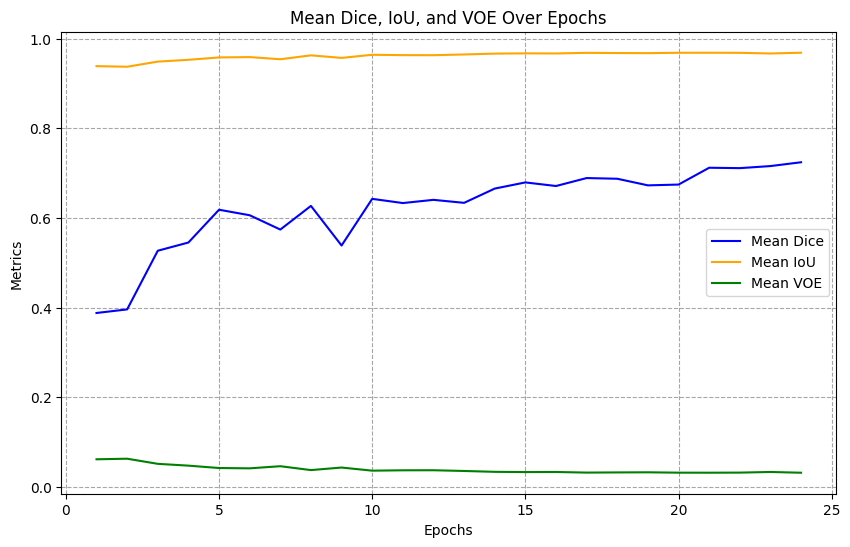

In [ ]:
import torch
import matplotlib.pyplot as plt
import os

# Define the path to your checkpoint file
checkpoint_path = os.path.join(root_dir, "best_metric_model.pth")

# Define function to load checkpoint
def load_checkpoint(path):
    try:
        checkpoint = torch.load(path)
        return (checkpoint['epoch'], checkpoint['best_metric'], checkpoint['best_metric_epoch'],
                checkpoint.get('epoch_loss_values', []), checkpoint.get('dice_values', []),
                checkpoint.get('voe_values', []), checkpoint.get('iou_values', []))
    except Exception as e:
        print(f"Error loading checkpoint: {e}")
        return 0, -1, -1, [], [], [], []

# Load metrics from checkpoint
start_epoch, best_metric, best_metric_epoch, epoch_loss_values, dice_values, voe_values, iou_values = load_checkpoint(checkpoint_path)

# Define epochs
epochs = range(1, len(dice_values) + 1)

# Plot mean Dice, mean IoU, and mean VOE on a single graph
plt.figure(figsize=(10, 6))

# Change marker style and line width to match the second plot style
plt.plot(epochs, dice_values, color='blue', label='Mean Dice', linewidth=1.5, marker='', linestyle='-')
plt.plot(epochs, iou_values, color='orange', label='Mean IoU', linewidth=1.5, marker='', linestyle='-')
plt.plot(epochs, voe_values, color='green', label='Mean VOE', linewidth=1.5, marker='', linestyle='-')

# Simplify the grid
plt.grid(True, linestyle='--', color='gray', alpha=0.7)

# Set labels and title
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Metrics', fontsize=10)
plt.title('Mean Dice, IoU, and VOE Over Epochs', fontsize=12)

# Add legend
plt.legend()

# Show the plot
plt.show()


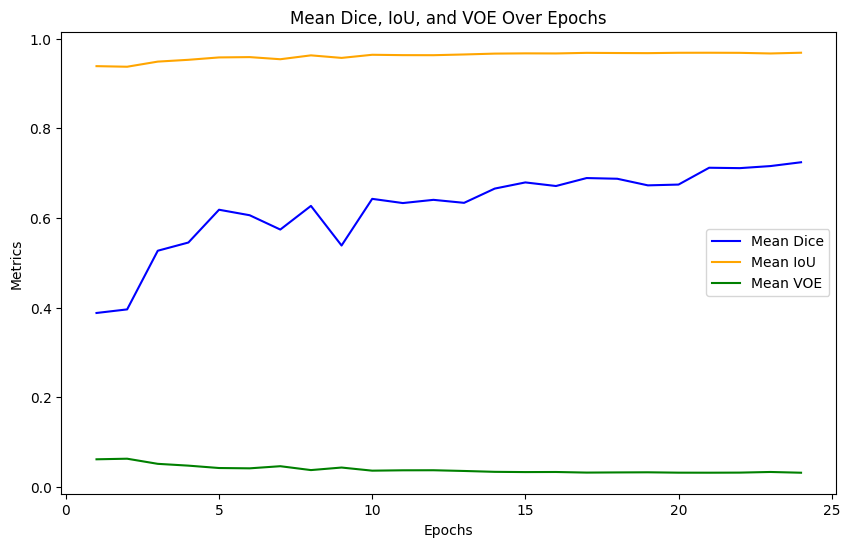

In [ ]:
import torch
import matplotlib.pyplot as plt
import os

# Define the path to your checkpoint file
checkpoint_path = os.path.join(root_dir, "best_metric_model.pth")

# Define function to load checkpoint
def load_checkpoint(path):
    try:
        checkpoint = torch.load(path)
        return (checkpoint['epoch'], checkpoint['best_metric'], checkpoint['best_metric_epoch'],
                checkpoint.get('epoch_loss_values', []), checkpoint.get('dice_values', []),
                checkpoint.get('voe_values', []), checkpoint.get('iou_values', []))
    except Exception as e:
        print(f"Error loading checkpoint: {e}")
        return 0, -1, -1, [], [], [], []

# Load metrics from checkpoint
start_epoch, best_metric, best_metric_epoch, epoch_loss_values, dice_values, voe_values, iou_values = load_checkpoint(checkpoint_path)

# Define epochs
epochs = range(1, len(dice_values) + 1)

# Plot mean Dice, mean IoU, and mean VOE on a single graph
plt.figure(figsize=(10, 6))

# Change marker style and line width to match the second plot style
plt.plot(epochs, dice_values, color='blue', label='Mean Dice', linewidth=1.5, marker='', linestyle='-')
plt.plot(epochs, iou_values, color='orange', label='Mean IoU', linewidth=1.5, marker='', linestyle='-')
plt.plot(epochs, voe_values, color='green', label='Mean VOE', linewidth=1.5, marker='', linestyle='-')

# Set labels and title
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Metrics', fontsize=10)
plt.title('Mean Dice, IoU, and VOE Over Epochs', fontsize=12)

# Add legend
plt.legend()

# Show the plot
plt.show()


torch.Size([1, 1, 128, 128, 128])


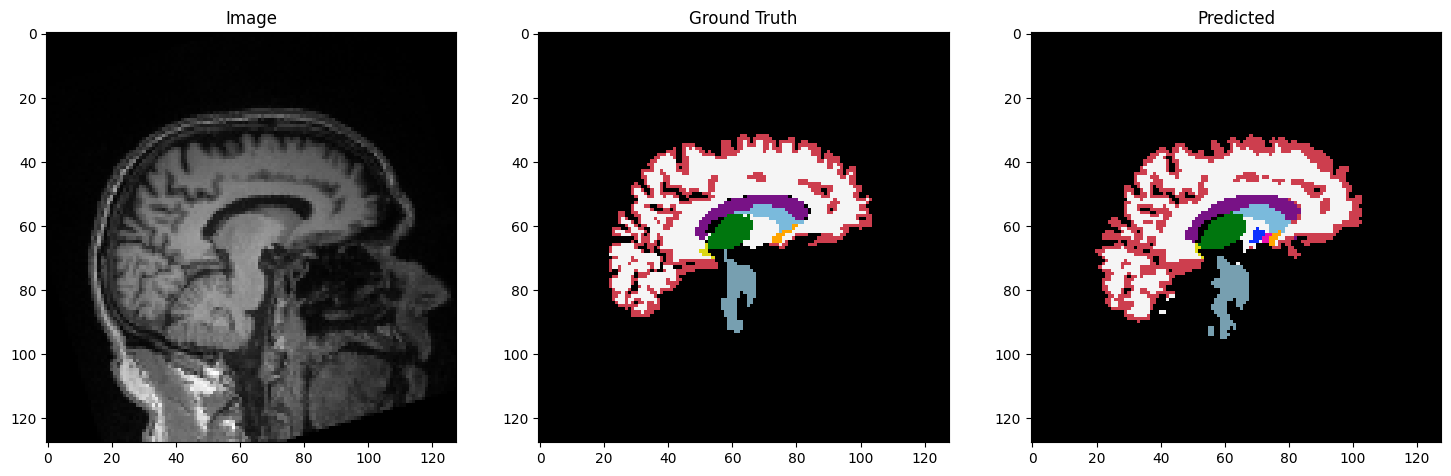

torch.Size([1, 1, 128, 128, 128])


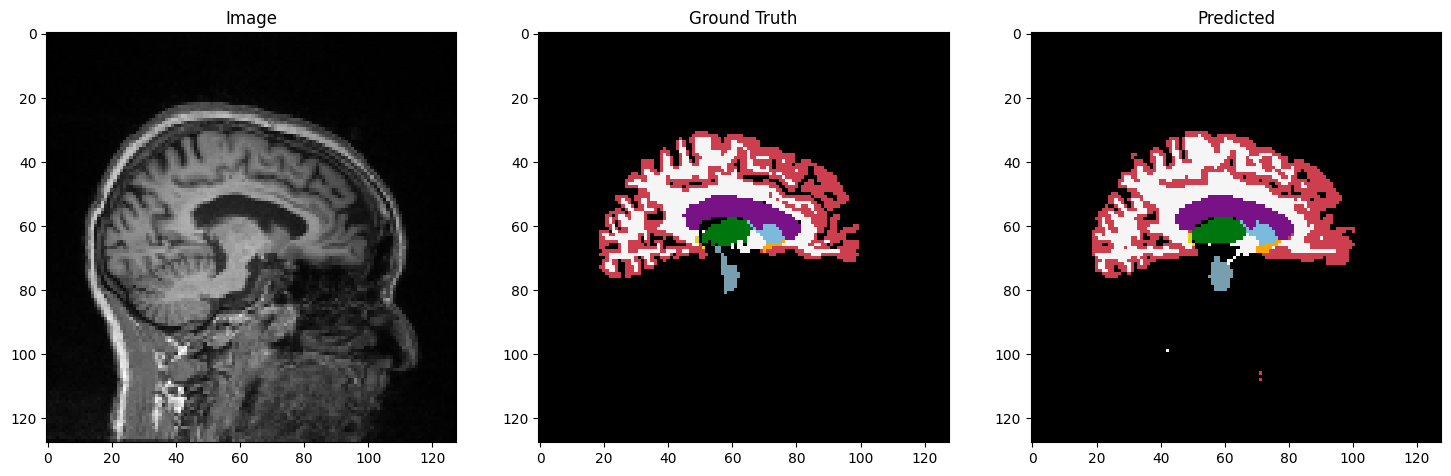

torch.Size([1, 1, 128, 128, 128])


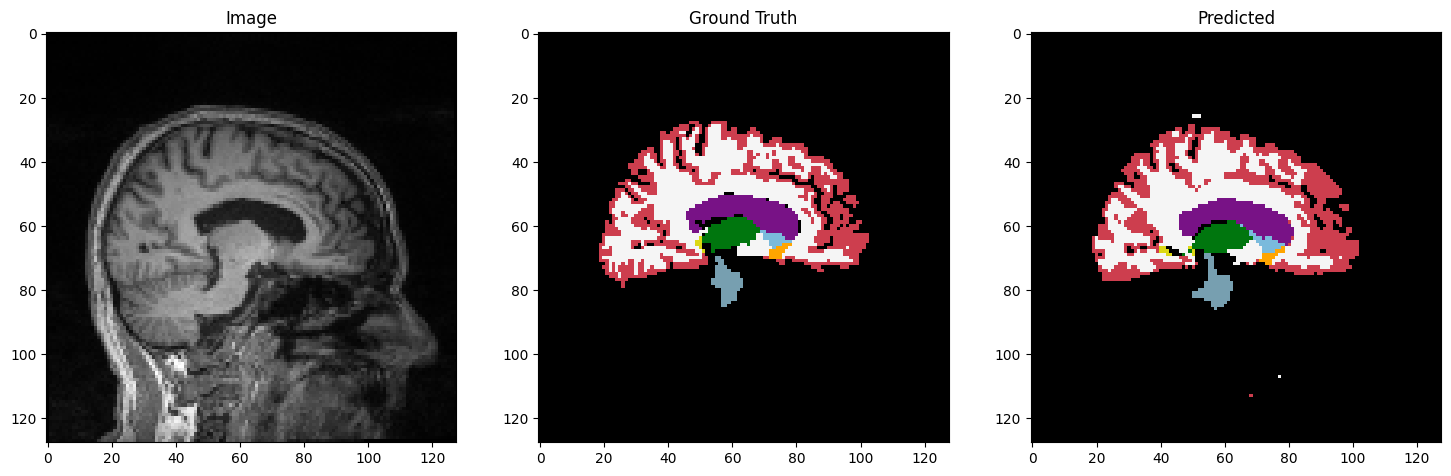

In [ ]:
checkpoint = torch.load(os.path.join(root_dir, "best_metric_model.pth"))

# Load the model state dictionary from the checkpoint
red_model.load_state_dict(checkpoint['model_state_dict'])
red_model.eval()

# Perform evaluation and visualization
with torch.no_grad():
    for i, val_data in enumerate(Red_val_loader):
        print(val_data['image'].shape)
        roi_size = (128, 128, 128)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(val_data["image"].to(device), roi_size, sw_batch_size, red_model)

        # Plot the slice [:, :, 59]
        plt.figure("check", (18, 6))
        plt.subplot(1, 3, 1)
        plt.title(f"Image")
        plt.imshow(val_data["image"][0, 0, 59, :, :].detach().cpu(), cmap="gray")

        plt.subplot(1, 3, 2)
        plt.title(f"Ground Truth")
        col_val_data = red_cmap_array1[val_data["label"][0, 0, :, :, :].detach().cpu().numpy().astype(np.int16)]
        plt.imshow(col_val_data[59, :, :])

        plt.subplot(1, 3, 3)
        plt.title(f"Predicted")
        col_val_out = red_cmap_array1[torch.argmax(val_outputs, dim=1)[0, :, :, :].detach().cpu().numpy().astype(np.int16)]
        plt.imshow(col_val_out[59, :, :])

        plt.show()

        if i == 2:
            break

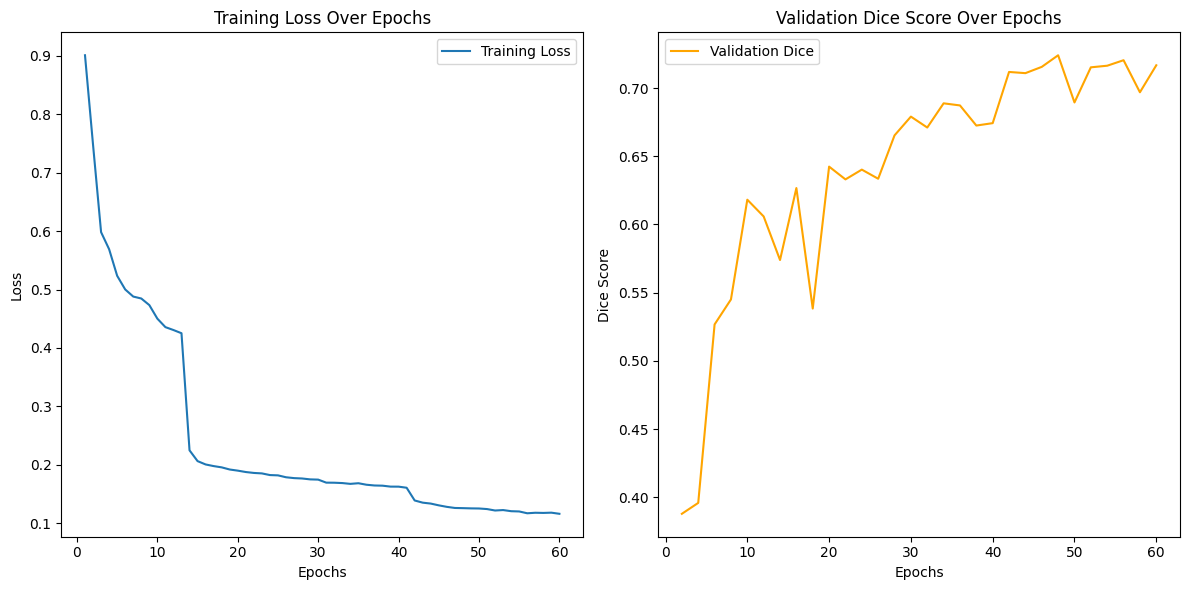

In [ ]:
import matplotlib.pyplot as plt

# Assuming epoch_loss_values and metric_values are lists storing the training loss and validation Dice score respectively.

# Plot the training loss and validation Dice score
plt.figure(figsize=(12, 6))

# Plotting training loss over epochs
plt.subplot(1, 2, 1)  # Changed to 1, 2, 1 to plot side by side
plt.plot(range(1, len(epoch_loss_values) + 1), epoch_loss_values, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# Plotting validation Dice score over epochs
plt.subplot(1, 2, 2)  # Changed to 1, 2, 2 to plot side by side
plt.plot(range(val_interval, len(dice_values) * val_interval + 1, val_interval), dice_values, label='Validation Dice', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.title('Validation Dice Score Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()


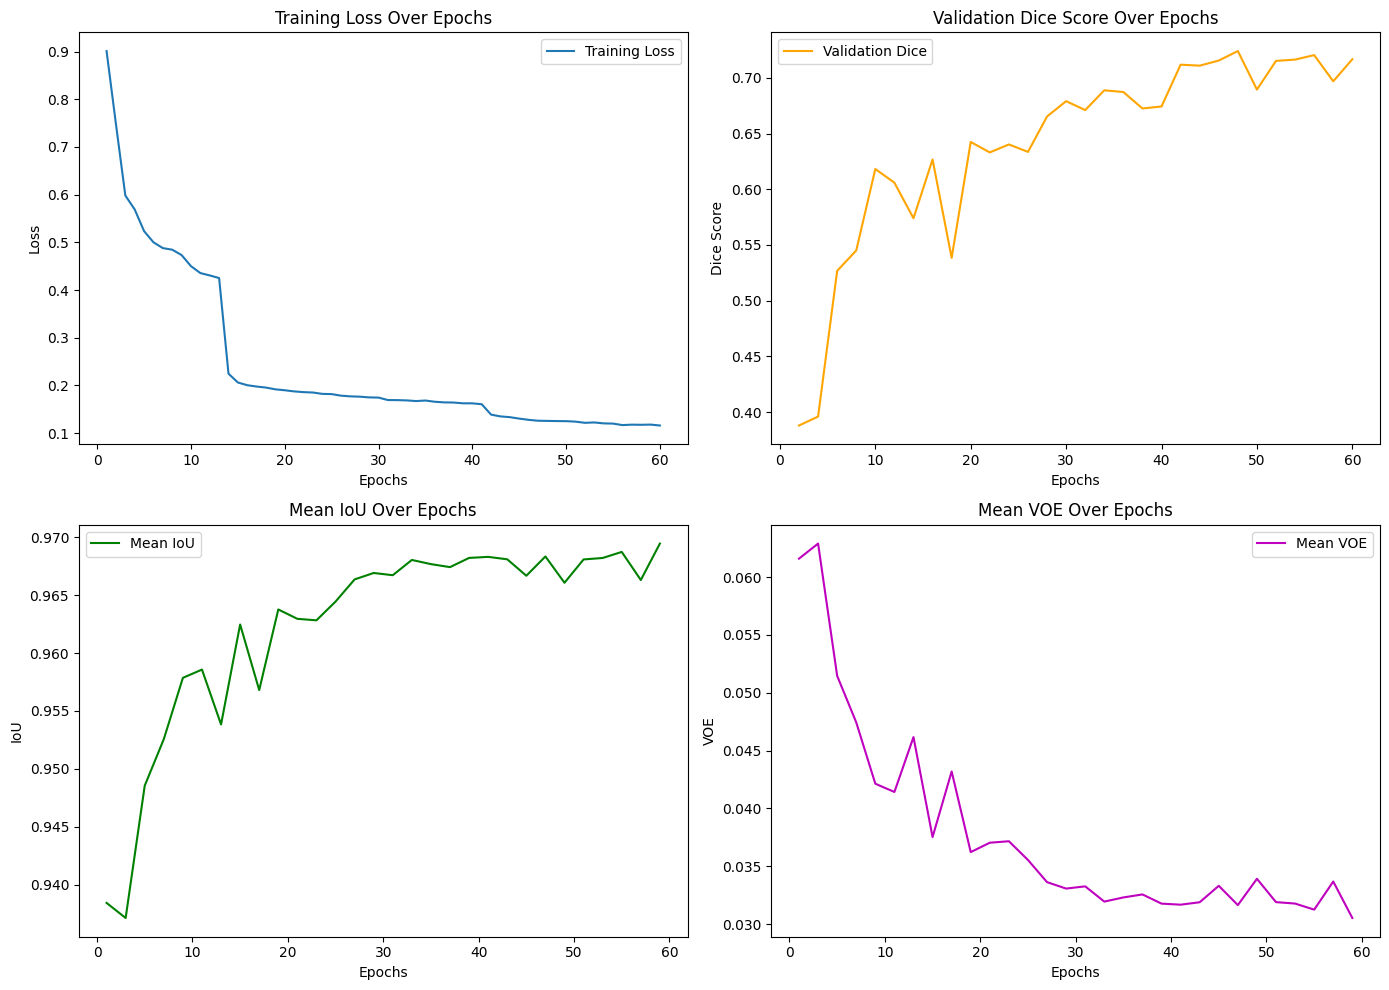

In [ ]:
import matplotlib.pyplot as plt

# Define the number of epochs
num_epochs = 60

# Define epochs array
epochs = range(1, num_epochs + 1)

# Length of available IoU and VOE values
iou_length = len(iou_values)
voe_length = len(voe_values)

# Define the epochs for which we have IoU and VOE values
# This assumes values are collected every 2 epochs (for example)
epochs_iou = range(1, iou_length * 2, 2)  # Adjust as needed
epochs_voe = range(1, voe_length * 2, 2)  # Adjust as needed

# Plotting training loss, validation Dice score, Mean IoU, and Mean VOE
plt.figure(figsize=(14, 10))

# Plotting training loss over epochs
plt.subplot(2, 2, 1)
plt.plot(range(1, len(epoch_loss_values) + 1), epoch_loss_values, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# Plotting validation Dice score over epochs
plt.subplot(2, 2, 2)
plt.plot(range(val_interval, len(dice_values) * val_interval + 1, val_interval), dice_values, label='Validation Dice', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.title('Validation Dice Score Over Epochs')
plt.legend()

# Plotting Mean IoU over epochs
plt.subplot(2, 2, 3)
plt.plot(epochs_iou, iou_values, 'g', label='Mean IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.title('Mean IoU Over Epochs')
plt.legend()

# Plotting Mean VOE over epochs
plt.subplot(2, 2, 4)
plt.plot(epochs_voe, voe_values, 'm', label='Mean VOE')
plt.xlabel('Epochs')
plt.ylabel('VOE')
plt.title('Mean VOE Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()


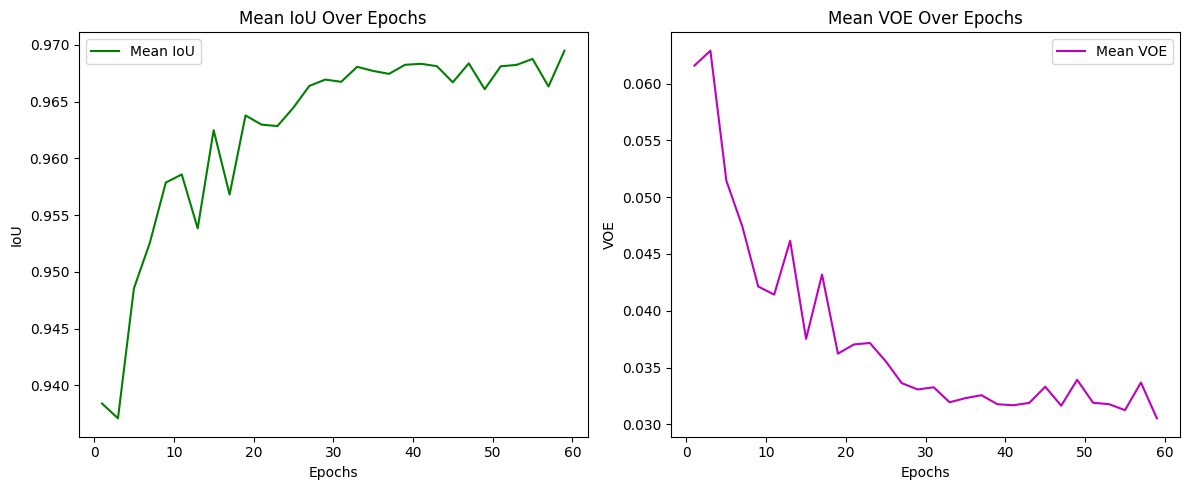

In [ ]:
import matplotlib.pyplot as plt

# Define the number of epochs
num_epochs = 60

# Define the available data length
iou_length = len(iou_values)  # Should be 30
voe_length = len(voe_values)  # Should be 30

# Define epochs array to match the length of IoU and VOE values
# Here, assume IoU and VOE values are recorded every 2 epochs
epochs_iou = range(1, num_epochs + 1, 2)  # Adjust if data is collected differently
epochs_voe = range(1, num_epochs + 1, 2)  # Adjust if data is collected differently

# Ensure that the length of epochs matches the length of IoU and VOE values
assert len(epochs_iou) == iou_length, "Mismatch between IoU data length and epochs length"
assert len(epochs_voe) == voe_length, "Mismatch between VOE data length and epochs length"

# Plot Mean IoU and Mean VOE
plt.figure(figsize=(12, 5))

# Plotting Mean IoU over epochs
plt.subplot(1, 2, 1)
plt.plot(epochs_iou, iou_values, 'g', label='Mean IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.title('Mean IoU Over Epochs')
plt.legend()

# Plotting Mean VOE over epochs
plt.subplot(1, 2, 2)
plt.plot(epochs_voe, voe_values, 'm', label='Mean VOE')
plt.xlabel('Epochs')
plt.ylabel('VOE')
plt.title('Mean VOE Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()


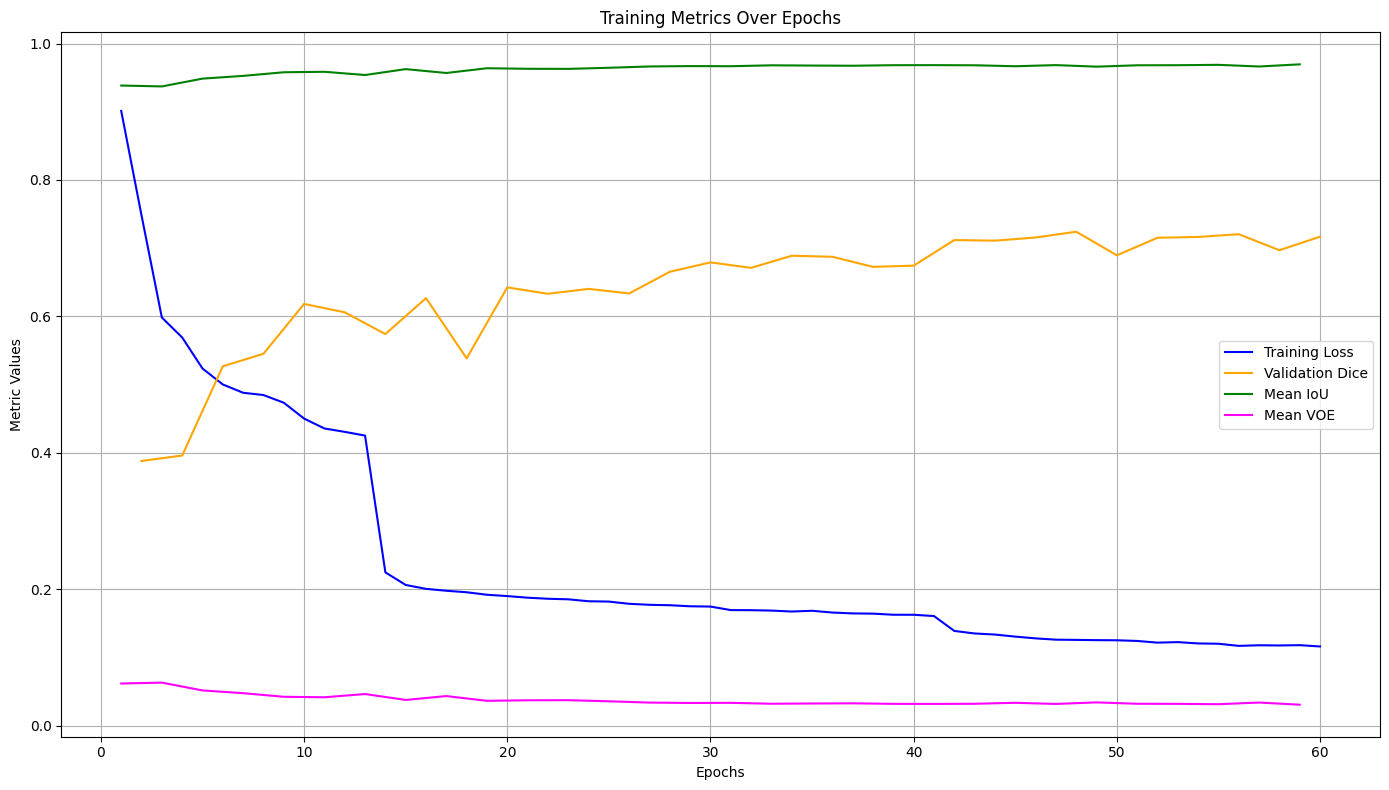

In [ ]:
import matplotlib.pyplot as plt

# Define the number of epochs
num_epochs = 60

# Define epochs array
epochs = range(1, num_epochs + 1)

# Length of available IoU and VOE values
iou_length = len(iou_values)
voe_length = len(voe_values)

# Define the epochs for which we have IoU and VOE values
# Adjust if the data is collected less frequently
epochs_iou = range(1, iou_length * 2, 2)
epochs_voe = range(1, voe_length * 2, 2)

# Plotting all metrics on the same graph
plt.figure(figsize=(14, 8))

# Plotting training loss
plt.plot(range(1, len(epoch_loss_values) + 1), epoch_loss_values, label='Training Loss', color='blue')

# Plotting validation Dice score
plt.plot(range(val_interval, len(dice_values) * val_interval + 1, val_interval), dice_values, label='Validation Dice', color='orange')

# Plotting Mean IoU
plt.plot(epochs_iou, iou_values, label='Mean IoU', color='green')

# Plotting Mean VOE
plt.plot(epochs_voe, voe_values, label='Mean VOE', color='magenta')

# Adding labels and title
plt.xlabel('Epochs')
plt.ylabel('Metric Values')
plt.title('Training Metrics Over Epochs')
plt.legend()  # Show legend

plt.grid(True)  # Optional: Add grid for better readability
plt.tight_layout()
plt.show()


In [ ]:
test_image_file_directory = "/content/drive/MyDrive/OASIS3_Dataset_Part4-20240315T141045Z-001/OASIS3_Dataset_Part4/Image_Folder"
test_label_file_directory = "/content/drive/MyDrive/OASIS3_Dataset_Part4-20240315T141045Z-001/OASIS3_Dataset_Part4/Label_Folder"
output_dir = '/content/drive/MyDrive/DSC_IOE_VOE_Segmented_Outputs'
os.makedirs(output_dir, exist_ok=True)

# Define test transforms
test_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    ToTensord(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Resized(keys=["image", "label"], spatial_size=(128, 128, 128), mode=['area', 'nearest']),
    ScaleIntensityd(keys="image", minv=0, maxv=1),
])

# Create test dataset and dataloader
test_image_files = sorted([os.path.join(test_image_file_directory, f) for f in os.listdir(test_image_file_directory) if f.endswith('.nii.gz')])
test_label_files = sorted([os.path.join(test_label_file_directory, f) for f in os.listdir(test_label_file_directory) if f.endswith('.nii.gz')])

test_data = [{'image': img, 'label': lbl} for img, lbl in zip(test_image_files, test_label_files)]
test_ds = Dataset(data=test_data, transform=test_transforms)
test_loader = DataLoader(test_ds, batch_size=1, num_workers=0)


In [ ]:
len(test_image_files),len(test_label_files)

(26, 26)

In [ ]:
checkpoint_path = os.path.join(root_dir, "best_metric_model.pth")
checkpoint = torch.load(checkpoint_path)

# Extract the model state dictionary
red_model.load_state_dict(checkpoint['model_state_dict'])
red_model.eval()

# Directory to save segmented outputs
output_dir = '/content/drive/MyDrive/DSC_IOE_VOE_Segmented_Outputs'
os.makedirs(output_dir, exist_ok=True)

# Apply post-processing transforms
post_pred = Compose([AsDiscrete(argmax=True, to_onehot=45)])

# Assuming `file_list` is a list of filenames corresponding to your validation set
# Replace `file_list` with the actual list of filenames
file_list = test_label_files  # Or image_files if you're using image filenames

with torch.no_grad():
    for i, val_data in enumerate(test_loader):
        val_inputs = val_data["image"].to(device)
        roi_size = (128, 128, 128)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, red_model)

        # Apply post-processing to each batch output
        val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]

        # Convert outputs to label format and save as 3D .nii files
        for j in range(val_inputs.shape[0]):
            output_image = torch.argmax(val_outputs[j], dim=0).detach().cpu().numpy()

            # Convert the output image to int16 to avoid compatibility issues
            output_image = output_image.astype(np.int16)

            # Get the original filename using the corresponding index in the list
            original_filename = os.path.basename(file_list[i * val_inputs.shape[0] + j])

            # Modify the filename to include "_segmented"
            output_filename = original_filename.replace(".nii.gz", "_segmented.nii.gz")

            # Create a NIfTI image
            nifti_image = nib.Nifti1Image(output_image, np.eye(4))

            # Save the NIfTI image to the specified directory
            nib.save(nifti_image, os.path.join(output_dir, output_filename))

        print(f"Processed and saved 3D NIfTI images for batch {i + 1}/{len(test_loader)}")

print(f"Inference and saving completed. Segmented 3D images saved at: {output_dir}")